<a href="https://colab.research.google.com/github/udikakumari2/Programming-assignment-02/blob/main/PA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dataset Description**

---

This research uses an artificial dataset compiled by me for detecting the players and keypoints from sports videos. This study involves 9 sports video clips collected from public online resources and arranged in the dataset. The video clips contain scenes from sports activities with different challenging situations such as many players, various camera perspectives, player actions, and sports environments.

This dataset includes several categories of sports videos such as football, rugby, basketball, and plays performed by students. All the video clips have 5-10 second lengths which meet the criteria of the assignment. The clips were saved in MP4 format and also included metadata with video ID, name, sport category, and download link.

The main purpose of creation this dataset is to test the performance of the YOLOv8-based player detection model and YOLOv8 pose estimation (keypoints detection). This dataset can be used as a benchmark for evaluating the performance of object detection and human pose estimation models.
| Attribute      | Description                    |
| -------------- | ------------------------------ |
| ID             | Unique identifier of the video |
| Name           | Video name                     |
| Sport Name     | Category of sport              |
| Link           | [link text](https://docs.google.com/spreadsheets/d/1Yx5mennlMv9ot2VZXMSDdVSM4-sIGI2g/edit?usp=sharing&ouid=113169337633899006557&rtpof=true&sd=true)       |
| Total Videos   | 9                              |
| Video Duration | 5–10 seconds                   |
| Video Format   | MP4                            |





# **1.Player Detection**

---





Build a vision model using a YOLO-like object detection framework to detect players in
the videos.

In [2]:

!pip install ultralytics gdown scikit-learn -q

from ultralytics import YOLO
import cv2
import pandas as pd
import gdown
import os
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score


model = YOLO("yolov8m.pt")

os.makedirs("output_videos", exist_ok=True)

df = pd.read_excel("Dataset For PA 2.xlsx")


def convert_drive_link(link):
    file_id = link.split('/d/')[1].split('/')[0]
    return f"https://drive.google.com/uc?id={file_id}"


y_true = []
y_pred = []


for index, row in df.iterrows():

    video_name = str(row['Name'])
    video_link = row['Link']

    print(f"\nProcessing: {video_name}")

    download_link = convert_drive_link(video_link)
    input_video = f"{video_name}.mp4"

    gdown.download(download_link,
                   input_video,
                   quiet=False)

    cap = cv2.VideoCapture(input_video)

    if not cap.isOpened():
        print("Cannot open video")
        continue

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    if fps == 0:
        fps = 30

    out = cv2.VideoWriter(
        f"output_videos/{video_name}_players.mp4",
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps,
        (width, height)
    )

    frame_count = 0

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        frame_count += 1


        results = model(frame, classes=[0])  # class 0 = person

        player_count = 0

        for result in results:

            boxes = result.boxes

            for box in boxes:

                x1, y1, x2, y2 = map(int, box.xyxy[0])
                confidence = float(box.conf[0])

                player_count += 1


                cv2.rectangle(frame,
                              (x1, y1),
                              (x2, y2),
                              (0,255,0),
                              2)


                cv2.putText(frame,
                            f"Player {confidence:.2f}",
                            (x1, y1-10),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.5,
                            (0,255,0),
                            2)


        y_true.append(1)
        y_pred.append(1 if player_count > 0 else 0)


        out.write(frame)

        if frame_count % 50 == 0:
            print(f"Processed {frame_count} frames")

    cap.release()
    out.release()

    print(f"Saved: output_videos/{video_name}_players.mp4")


print("\nCalculating Metrics...")

acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)


Processing: Video 1


Downloading...
From: https://drive.google.com/uc?id=18Qiii9oc0UHEYDC8mMbMuo3TolUvI-NC
To: /content/Video 1.mp4
100%|██████████| 2.36M/2.36M [00:00<00:00, 158MB/s]



0: 384x640 19 persons, 1023.5ms
Speed: 4.5ms preprocess, 1023.5ms inference, 9.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 15 persons, 924.4ms
Speed: 3.6ms preprocess, 924.4ms inference, 3.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 15 persons, 1462.6ms
Speed: 3.8ms preprocess, 1462.6ms inference, 4.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 16 persons, 1483.7ms
Speed: 6.8ms preprocess, 1483.7ms inference, 4.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 16 persons, 1258.9ms
Speed: 4.6ms preprocess, 1258.9ms inference, 3.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 15 persons, 905.3ms
Speed: 3.4ms preprocess, 905.3ms inference, 3.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 15 persons, 1006.2ms
Speed: 3.7ms preprocess, 1006.2ms inference, 3.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 16 persons, 948.6ms
Speed: 3.4ms preprocess, 948.6ms inference, 2.9m

Downloading...
From: https://drive.google.com/uc?id=1CWklm6hdXKal31mWTaCxl9zwU62rqZ6x
To: /content/Video 2.mp4
100%|██████████| 1.64M/1.64M [00:00<00:00, 106MB/s]

0: 384x640 13 persons, 983.2ms
Speed: 4.1ms preprocess, 983.2ms inference, 3.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 15 persons, 966.6ms
Speed: 3.8ms preprocess, 966.6ms inference, 3.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 13 persons, 929.7ms
Speed: 4.5ms preprocess, 929.7ms inference, 2.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 16 persons, 953.8ms
Speed: 3.3ms preprocess, 953.8ms inference, 3.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 13 persons, 953.3ms
Speed: 3.5ms preprocess, 953.3ms inference, 2.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 13 persons, 988.8ms
Speed: 3.3ms preprocess, 988.8ms inference, 3.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 13 persons, 896.9ms
Speed: 2.7ms preprocess, 896.9ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 13 persons, 932.8ms
Speed: 3.0ms preprocess, 932.8ms inference, 2.8ms postproce

...

Downloading...
From: https://drive.google.com/uc?id=1nzUpmsen-XEguDxstSyObYDjpYEBQiqv
To: /content/Video 8.mp4
100%|██████████| 46.8M/46.8M [00:00<00:00, 61.3MB/s]



0: 384x640 26 persons, 911.3ms
Speed: 8.8ms preprocess, 911.3ms inference, 4.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 24 persons, 939.1ms
Speed: 4.6ms preprocess, 939.1ms inference, 4.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 26 persons, 923.3ms
Speed: 8.1ms preprocess, 923.3ms inference, 4.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 27 persons, 1242.7ms
Speed: 4.0ms preprocess, 1242.7ms inference, 6.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 26 persons, 1455.6ms
Speed: 4.9ms preprocess, 1455.6ms inference, 7.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 30 persons, 1056.0ms
Speed: 12.5ms preprocess, 1056.0ms inference, 4.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 26 persons, 925.5ms
Speed: 4.0ms preprocess, 925.5ms inference, 4.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 28 persons, 921.9ms
Speed: 7.6ms preprocess, 921.9ms inference, 4.7ms p

Downloading...
From: https://drive.google.com/uc?id=19k_w51nWju8kDSz4wgfj2F6hFv9_YEAi
To: /content/Video 9.mp4
100%|██████████| 25.6M/25.6M [00:00<00:00, 34.8MB/s]

0: 640x384 4 persons, 943.9ms
Speed: 4.3ms preprocess, 943.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 4 persons, 934.1ms
Speed: 3.7ms preprocess, 934.1ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 4 persons, 1408.1ms
Speed: 3.7ms preprocess, 1408.1ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 4 persons, 1435.7ms
Speed: 5.7ms preprocess, 1435.7ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 3 persons, 989.0ms
Speed: 3.9ms preprocess, 989.0ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 3 persons, 927.4ms
Speed: 3.9ms preprocess, 927.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 4 persons, 930.4ms
Speed: 4.5ms preprocess, 930.4ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 4 persons, 920.5ms
Speed: 5.9ms preprocess, 920.5ms inference, 2.3ms postprocess p

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


# **2.Keypoint Detection**





---


Implement a model similar to OpenPose to identify player keypoints (e.g., hands, legs,
body joints).

In [ ]:
!pip install scikit-learn seaborn matplotlib

ERROR: Operation cancelled by user

Processing: Video 1


Downloading...
From: https://drive.google.com/uc?id=18Qiii9oc0UHEYDC8mMbMuo3TolUvI-NC
To: /content/Video 1.mp4
100%|██████████| 2.36M/2.36M [00:00<00:00, 156MB/s]

0: 384x640 2 persons, 180.8ms
Speed: 12.9ms preprocess, 180.8ms inference, 4.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 191.6ms
Speed: 4.1ms preprocess, 191.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 147.1ms
Speed: 3.9ms preprocess, 147.1ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 168.0ms
Speed: 3.2ms preprocess, 168.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 147.9ms
Speed: 4.2ms preprocess, 147.9ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 147.3ms
Speed: 3.5ms preprocess, 147.3ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 145.5ms
Speed: 3.2ms preprocess, 145.5ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 147.6ms
Speed: 3.7ms preprocess, 147.6ms inference, 1.3ms postprocess per

Downloading...
From: https://drive.google.com/uc?id=1CWklm6hdXKal31mWTaCxl9zwU62rqZ6x
To: /content/Video 2.mp4
100%|██████████| 1.64M/1.64M [00:00<00:00, 144MB/s]


0: 384x640 (no detections), 143.8ms
Speed: 3.3ms preprocess, 143.8ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)



...

Downloading...
From: https://drive.google.com/uc?id=1nzUpmsen-XEguDxstSyObYDjpYEBQiqv
To: /content/Video 8.mp4
100%|██████████| 46.8M/46.8M [00:00<00:00, 47.8MB/s]



0: 384x640 3 persons, 167.2ms
Speed: 6.0ms preprocess, 167.2ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 persons, 185.4ms
Speed: 9.2ms preprocess, 185.4ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 persons, 168.2ms
Speed: 4.6ms preprocess, 168.2ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 persons, 173.5ms
Speed: 3.9ms preprocess, 173.5ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 persons, 184.2ms
Speed: 5.0ms preprocess, 184.2ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 persons, 190.5ms
Speed: 4.2ms preprocess, 190.5ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 persons, 196.5ms
Speed: 4.2ms preprocess, 196.5ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 6 persons, 179.0ms
Speed: 4.3ms preprocess, 179.0ms inference, 1.5ms postprocess per 

Downloading...
From: https://drive.google.com/uc?id=19k_w51nWju8kDSz4wgfj2F6hFv9_YEAi
To: /content/Video 9.mp4
100%|██████████| 25.6M/25.6M [00:00<00:00, 53.5MB/s]



0: 640x384 3 persons, 242.0ms
Speed: 7.6ms preprocess, 242.0ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 3 persons, 233.7ms
Speed: 11.5ms preprocess, 233.7ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 3 persons, 251.6ms
Speed: 6.8ms preprocess, 251.6ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 3 persons, 242.9ms
Speed: 14.0ms preprocess, 242.9ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 2 persons, 231.1ms
Speed: 10.1ms preprocess, 231.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 3 persons, 228.8ms
Speed: 9.2ms preprocess, 228.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 2 persons, 261.6ms
Speed: 11.7ms preprocess, 261.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 2 persons, 240.0ms
Speed: 5.7ms preprocess, 240.0ms inference, 1.5ms postprocess 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1179: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


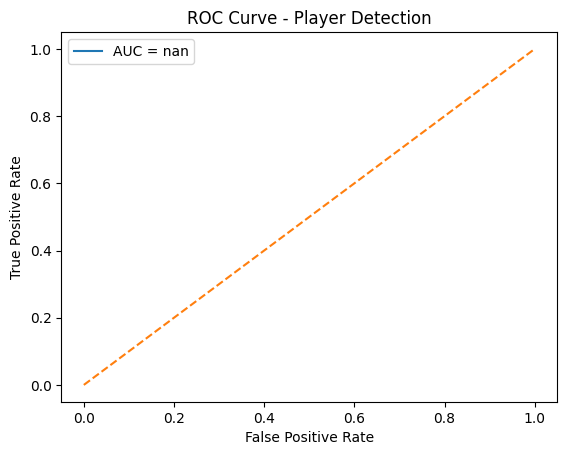

In [3]:

!pip install ultralytics gdown scikit-learn -q

from ultralytics import YOLO
import cv2
import pandas as pd
import gdown
import os
import numpy as np

from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt


model = YOLO("yolov8n-pose.pt")

os.makedirs("output_videos", exist_ok=True)

df = pd.read_excel("Dataset For PA 2.xlsx")



def convert_drive_link(link):
    file_id = link.split('/d/')[1].split('/')[0]
    return f"https://drive.google.com/uc?id={file_id}"



y_true = []
y_scores = []



for index, row in df.iterrows():

    video_name = str(row['Name'])
    video_link = row['Link']

    print(f"\nProcessing: {video_name}")

    # download
    download_link = convert_drive_link(video_link)
    input_video = f"{video_name}.mp4"

    gdown.download(download_link, input_video, quiet=False)

    cap = cv2.VideoCapture(input_video)

    if not cap.isOpened():
        print("Cannot open video")
        continue

    width = int(cap.get(3))
    height = int(cap.get(4))
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps == 0:
        fps = 30

    out = cv2.VideoWriter(
        f"output_videos/{video_name}_keypoints.mp4",
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps,
        (width, height)
    )

    frame_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1


        results = model(frame)

        annotated = frame.copy()

        person_detected = 0

        for r in results:

            if r.keypoints is not None:

                keypoints = r.keypoints.xy.cpu().numpy()

                for person in keypoints:
                    person_detected += 1

                    for point in person:
                        x, y = int(point[0]), int(point[1])
                        cv2.circle(annotated, (x, y), 3, (0, 255, 0), -1)



        y_true.append(1)
        y_scores.append(min(person_detected / 5.0, 1.0))


        out.write(annotated)

    cap.release()
    out.release()

    print(f"Saved: output_videos/{video_name}_keypoints.mp4")




print("\nCalculating Metrics...")

# Binary prediction
y_pred = [1 if s > 0.5 else 0 for s in y_scores]

# Accuracy
acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)


cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)


fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Player Detection")
plt.legend()
plt.show()